# Étape 3 — Clustering & validation des profils (V2 — seuil de variance AFTD)

**Projet SY09 — Décrochage scolaire en mathématiques**  
Notebook 3/3 · Distance mixte (§2.2) · AFTD (Ch. 6) · CAH-Ward + K-means (Ch. 7) · Validation statistique & externe

---

## Contexte

Ce notebook identifie des profils d'élèves à partir de 8 variables socio-comportementales
disponibles en début d'année, puis valide statistiquement et extérieurement ces profils.
Le décrochage (G3=0, G1>0) touche 9,6 % des élèves en maths (38 élèves sur 395).
Le clustering porte sur l'intégralité du jeu (mat_full, 395 élèves). Le seuil de variance
AFTD retenu est 58 %, ce qui donne **3 axes factoriels** (inertie cumulée : 58,1 %) ;
le nombre de clusters K est choisi automatiquement par silhouette et vaut **K = 4**.

**Plan :**
1. Imports et chargement
2. Sélection de variables — rappel et justification
3. Distance mixte (cours §2.2)
4. AFTD — seuil de variance, scree plot, Shepard, contributions (cours Ch. 6)
5. CAH-Ward — dendrogramme, sauts d'inertie (cours Ch. 7 §5.5)
6. K-means — coude + silhouette, choix automatique de K (cours Ch. 7 §6.1)
7. Comparaison ARI (cours §7)
8. Caractérisation descriptive des profils
9. Synthèse de l'étape non supervisée
10. Validation statistique — les profils existent-ils vraiment ?
11. Stabilité — les clusters résistent-ils à des sous-échantillons ?
12. Validation externe par les trajectoires de notes
13. Cohérence élargie — variables non utilisées dans le clustering
14. Membres typiques et atypiques
15. Usage opérationnel — score de proximité
16. Synthèse de la validation des profils


---
## 1. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, fisher_exact
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DATA_PATH = 'Data/student-mat.csv'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
BLEU   = '#2196F3'
ROUGE  = '#E53935'
VERT   = '#43A047'
ORANGE = '#FB8C00'
PAL    = [BLEU, ROUGE, VERT, ORANGE]

from pathlib import Path
FIG_DIR = Path('RAPPORT/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
mat_full = pd.read_csv(DATA_PATH, sep=',')

# Variable cible définie en notebook 1 : G3=0 ET G1>0
mat_full['decrocheur'] = ((mat_full['G3'] == 0) & (mat_full['G1'] > 0)).astype(int)

print(f"Dataset : {mat_full.shape[0]} élèves — {mat_full['decrocheur'].sum()} décrocheurs ({100*mat_full['decrocheur'].mean():.1f} %)")


Dataset : 395 élèves — 38 décrocheurs (9.6 %)


## 2. Sélection des variables

Les tests Mann-Whitney et χ² réalisés en notebook 0 (cf. `00_analyse_preliminaire.ipynb`)
ont identifié 8 variables à pouvoir discriminant vis-à-vis du décrochage, en retenant
α = 0,10 — seuil justifié par le faible effectif des décrocheurs (n = 38) qui limite la
puissance des tests.

`absences` est écartée malgré sa p-valeur < 0,001. Les décrocheurs affichent
paradoxalement 0,00 absence en moyenne contre 6,32 pour les non-décrocheurs —
un résultat contre-intuitif dont l'interprétation est ambiguë : arrêt de la
comptabilisation après abandon administratif, problème de saisie, ou comportement
réel. Faute de pouvoir interpréter ce signal de façon fiable, la variable est
exclue plutôt que de construire un raisonnement sur une base incertaine.

Les 8 variables retenues sont :

| Variable | Type | p-valeur |
|----------|------|----------|
| `failures` | Numérique | < 0,001 |
| `Medu` | Numérique | 0,008 |
| `age` | Numérique | 0,039 |
| `Walc` | Numérique | 0,060 |
| `paid` | Catégorielle | 0,002 |
| `higher` | Catégorielle | 0,005 |
| `romantic` | Catégorielle | 0,014 |
| `schoolsup` | Catégorielle | 0,083 |

## 3. Distance mixte — cadre théorique du cours (§2.2)

Le cours SY09 (Ch. 2, §2.2) définit des distances adaptées à chaque type de variable.
Nos 8 variables retenues sont de deux natures :

**Variables ordinales** (`failures`, `Medu`, `age`, `Walc`) — distance sur rang renormalisé :
$$d_k(i,j) = \frac{|x_{ik} - x_{jk}|}{\max_k - \min_k}$$

**Variables binaires** (`higher`, `paid`, `romantic`, `schoolsup`) — désaccord simple :
$$d_k(i,j) = 1 - \mathbf{1}[x_{ik} = x_{jk}]$$

**Distance globale** (Gower 1971 — extension du cadre §2.2) :
$$d(i,j) = \frac{1}{8} \sum_{k=1}^{8} d_k(i,j) \in [0,1]$$

> **Remarque :** le cours (Ch. 6, §5.2) précise que si $\Delta$ n'est pas euclidienne,
> la matrice $W = -\frac{1}{2} Q_n \Delta^2 Q_n$ peut présenter des valeurs propres
> négatives. Ce cas est **attendu** pour les distances mixtes et sera vérifié en section 4.

In [3]:
VARS_NUM = ['failures', 'Medu', 'age', 'Walc']
VARS_CAT = ['higher', 'paid', 'schoolsup', 'romantic']

# Encodage binaire yes/no → 1/0
df_bin = mat_full[VARS_CAT].apply(lambda col: (col == 'yes').astype(float))
df_num = mat_full[VARS_NUM].copy()

n = len(mat_full)
D = np.zeros((n, n))

# Bloc numérique : |xi−xj| / range  (cours §2.2 — variable ordinale)
for col in VARS_NUM:
    v = df_num[col].values.astype(float)
    r = v.max() - v.min()
    if r > 0:
        D += np.abs(v[:,None] - v[None,:]) / r

# Bloc binaire : désaccord simple  (cours §2.2 — variable binaire)
for col in VARS_CAT:
    v = df_bin[col].values
    D += (v[:,None] != v[None,:]).astype(float)

D /= (len(VARS_NUM) + len(VARS_CAT))   # normalisation → D ∈ [0,1]
np.fill_diagonal(D, 0)

print("=== Propriétés de la matrice Δ ===")
print(f"Dimension          : {D.shape}")
print(f"Min / Max          : {D.min():.4f} / {D.max():.4f}")
print(f"Diagonale nulle    : {np.allclose(np.diag(D), 0)}")
print(f"Symétrique         : {np.allclose(D, D.T)}")

# Vérification euclidianité (cours §5.2)
Qn     = np.eye(n) - np.ones((n,n))/n
W_test = -0.5 * Qn @ (D**2) @ Qn
ev_test = np.linalg.eigvalsh(W_test)
n_neg   = (ev_test < -1e-8).sum()
print(f"Val. propres négatives : {n_neg}/{n}  (min = {ev_test[ev_test<0].min():.4f})")
print("→ Distance non euclidienne — comportement attendu pour données mixtes (cours §5.2)")

# Helpers Gower (réutilisés sections 14–15)
ranges_num = {col: (mat_full[col].min(), mat_full[col].max()) for col in VARS_NUM}


def encode_row(row):
    """Encode une ligne mat_full en vecteur numérique (8 variables)."""
    vals = [float(row[col]) for col in VARS_NUM]
    vals += [float(row[col] == 'yes') for col in VARS_CAT]
    return np.array(vals, dtype=float)


def gower_distance(a, b, ranges_num):
    """Distance mixte de Gower entre deux vecteurs encodés (8 variables)."""
    d = 0.0
    for i, col in enumerate(VARS_NUM):
        r_min, r_max = ranges_num[col]
        r = r_max - r_min
        d += abs(a[i] - b[i]) / r if r > 0 else 0.0
    offset = len(VARS_NUM)
    for j, _ in enumerate(VARS_CAT):
        d += float(a[offset + j] != b[offset + j])
    return d / (len(VARS_NUM) + len(VARS_CAT))


=== Propriétés de la matrice Δ ===
Dimension          : (395, 395)
Min / Max          : 0.0000 / 0.9062
Diagonale nulle    : True
Symétrique         : True
Val. propres négatives : 129/395  (min = -1.5386)
→ Distance non euclidienne — comportement attendu pour données mixtes (cours §5.2)


## 4. AFTD — Analyse Factorielle d'un Tableau de Distances

### 4.1 Rappel théorique (cours Ch. 6)

L'AFTD cherche une représentation $X$ dans $\mathbb{R}^p$ reproduisant au mieux la
dissimilarité initiale $\Delta$.

**1. Double-centrage :**
$$W = -\tfrac{1}{2} Q_n \Delta^2 Q_n \quad \text{où} \quad Q_n = I_n - \tfrac{1}{n}\mathbf{1}\mathbf{1}^T$$

**2. Décomposition spectrale de W :**
$$\mathbf{c}_\alpha = \sqrt{\lambda_\alpha} \cdot \mathbf{u}_\alpha$$

La distance mixte construite en section 3 n'étant pas euclidienne, $W$ présente des
valeurs propres négatives — comportement attendu et vérifié. On ne conserve donc que
les valeurs propres **positives** pour calculer les coordonnées factorielles, et le
pourcentage d'inertie expliqué est calculé sur leur **somme uniquement** (cours §5.2).

Le nombre de dimensions retenues se choisit par la **méthode du coude** (§6.1) et se
vérifie avec le **diagramme de Shepard** (§6.2).

### 4.1b Paramètres — seuil de variance et visualisation 3D

Le nombre d'axes retenus pour l'AFTD est déterminé automatiquement à partir du
**seuil de variance cumulée** `VARIANCE_THRESHOLD` (entre 0 et 1).
Exemples sur nos données : `0.45` ≈ 2 axes (équivalent V1), `0.80` ≈ 5–6 axes.

Ce seuil s'applique à l'inertie cumulée calculée sur les **valeurs propres positives
uniquement** (cours §5.2). Les coordonnées retenues alimentent ensuite CAH-Ward et K-means.

Si `SHOW_3D_SCATTER = True` **et** `n_axes ≥ 3`, un nuage **3D interactif** (Plotly,
axes 1–2–3 : rotation, zoom, survol) complète le plan 1–2 statique (Matplotlib).

In [4]:
# Seuil de variance cumulée à conserver (0 < seuil ≤ 1)
# Ex. 0.45 ≈ 2 axes (V1), 0.80 ≈ 5–6 axes
VARIANCE_THRESHOLD = 0.58

# Nuage 3D (axes 1–2–3) si n_axes > 3
SHOW_3D_SCATTER = True

def n_axes_for_threshold(cum_inertia, threshold):
    """Premier indice où l'inertie cumulée atteint le seuil (cum_inertia en fraction 0–1)."""
    idx = np.where(cum_inertia >= threshold)[0]
    return int(idx[0] + 1) if len(idx) else len(cum_inertia)


In [5]:
# Double-centrage  W = -1/2 * Qn * Δ² * Qn  (cours Ch. 6)
Qn = np.eye(n) - np.ones((n,n))/n
W  = -0.5 * Qn @ (D**2) @ Qn

# Décomposition spectrale
eigvals_all, eigvecs_all = np.linalg.eigh(W)
idx     = np.argsort(eigvals_all)[::-1]
eigvals = eigvals_all[idx]
eigvecs = eigvecs_all[:, idx]

# Coordonnées factorielles — valeurs propres positives seulement (cours §5.2)
pos = eigvals > 1e-8
lam = eigvals[pos]
U   = eigvecs[:, pos]
C   = U * np.sqrt(lam)[None,:]          # (n × r) — c_α = √λ_α · u_α

inertie_totale = lam.sum()              # somme des VP positives uniquement
pct = 100 * lam / inertie_totale

print("Valeurs propres et inerties expliquées (VP positives uniquement)")
print(f"{'Axe':>4} {'λ':>10} {'Inertie %':>11} {'Cumulée %':>11}")
print("-" * 42)
cumul = 0
n_show = min(12, pos.sum())
for i in range(n_show):
    cumul += pct[i]
    print(f"{i+1:>4} {lam[i]:>10.4f} {pct[i]:>10.2f}% {cumul:>10.2f}%")

print(f"\nVal. propres positives : {pos.sum()}")
print(f"Val. propres négatives : {(~pos).sum()}  (min = {eigvals[~pos].min():.4f})")
# Choix automatique du nombre d'axes selon le seuil de variance
cum_var = np.cumsum(pct) / 100.0
n_axes = n_axes_for_threshold(cum_var, VARIANCE_THRESHOLD)
C_sel = C[:, :n_axes]
print(f"\n→ Seuil {VARIANCE_THRESHOLD:.0%} → {n_axes} axes retenus (inertie cumulée : {cum_var[n_axes-1]:.1%})")


Valeurs propres et inerties expliquées (VP positives uniquement)
 Axe          λ   Inertie %   Cumulée %
------------------------------------------
   1     8.1119      24.11%      24.11%
   2     6.9812      20.75%      44.85%
   3     4.4665      13.27%      58.12%
   4     3.1603       9.39%      67.52%
   5     2.9371       8.73%      76.24%
   6     1.7954       5.34%      81.58%
   7     1.3732       4.08%      85.66%
   8     1.0535       3.13%      88.79%
   9     0.7327       2.18%      90.97%
  10     0.6729       2.00%      92.97%
  11     0.4655       1.38%      94.35%
  12     0.4515       1.34%      95.69%

Val. propres positives : 20
Val. propres négatives : 375  (min = -1.5386)

→ Seuil 58% → 3 axes retenus (inertie cumulée : 58.1%)


### 4.2 Choix du nombre d'axes — méthode du coude et diagramme de Shepard

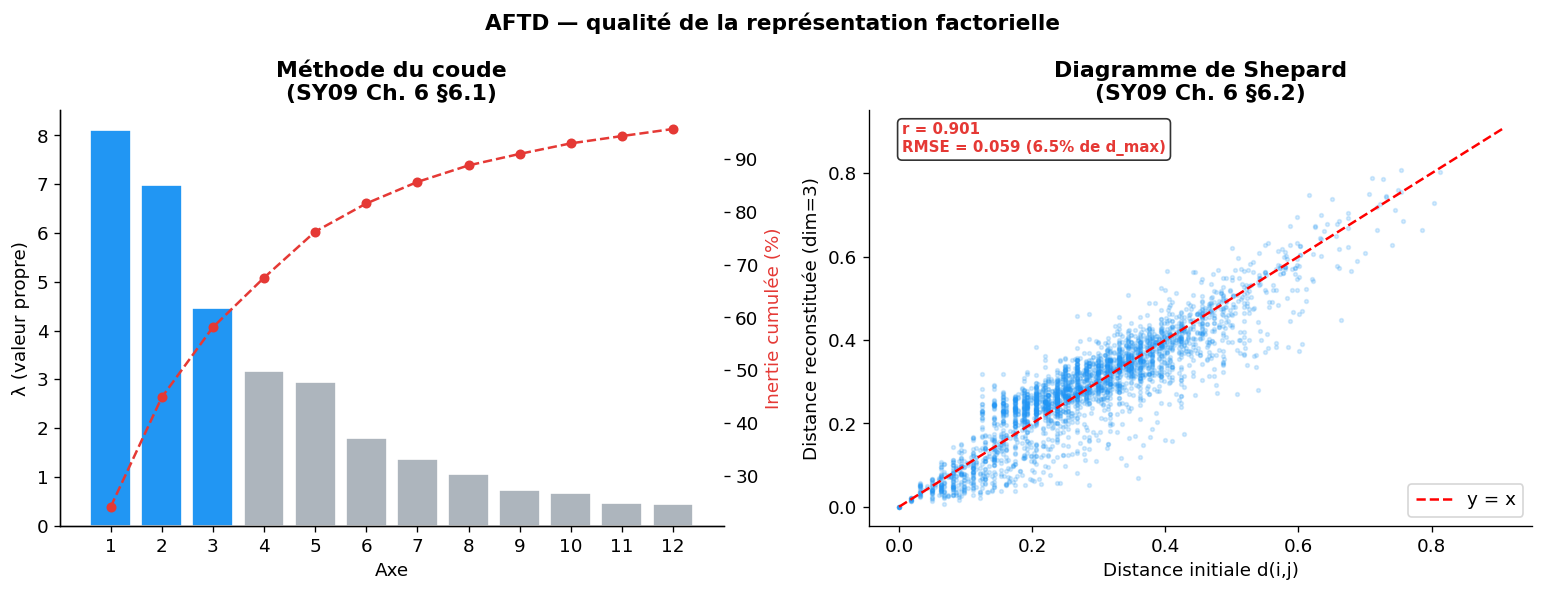

→ Axes retenus : 3  |  Inertie cumulée : 58.1%
  Shepard r = 0.901  |  RMSE = 0.059 (6.5% de d_max)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Scree plot (méthode du coude, cours §6.1) ──
ax = axes[0]
k_show = min(12, pos.sum())
bars_color = [BLEU if i < n_axes else '#adb5bd' for i in range(k_show)]
ax.bar(range(1, k_show+1), lam[:k_show], color=bars_color, edgecolor='white')
ax2_tw = ax.twinx()
cumul_pct = np.cumsum(pct[:k_show])
ax2_tw.plot(range(1, k_show+1), cumul_pct, 'o--', color=ROUGE, ms=5, lw=1.5)
ax2_tw.set_ylabel('Inertie cumulée (%)', color=ROUGE)
ax.set_xlabel('Axe')
ax.set_ylabel('λ (valeur propre)')
ax.set_title('Méthode du coude\n(SY09 Ch. 6 §6.1)', fontweight='bold')
ax.set_xticks(range(1, k_show+1))

# ── Diagramme de Shepard (cours §6.2) ──
# Coordonnées retenues selon VARIANCE_THRESHOLD (calculées en cellule précédente)
ax2 = axes[1]
idx_tri = np.triu_indices(n, k=1)
d_init  = D[idx_tri]
D_rec   = cdist(C_sel, C_sel)
d_rec   = D_rec[idx_tri]
rng = np.random.default_rng(42)
spl = rng.choice(len(d_init), 3000, replace=False)
ax2.scatter(d_init[spl], d_rec[spl], alpha=0.18, s=5, color=BLEU)
ax2.plot([0, d_init.max()], [0, d_init.max()], 'r--', lw=1.5, label='y = x')
r_shep    = np.corrcoef(d_init, d_rec)[0,1]
rmse_shep = np.sqrt(np.mean((d_init - d_rec)**2))
ax2.text(0.05, 0.90,
         f'r = {r_shep:.3f}\nRMSE = {rmse_shep:.3f} ({100*rmse_shep/d_init.max():.1f}% de d_max)',
         transform=ax2.transAxes, fontsize=9, fontweight='bold', color=ROUGE,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax2.set_xlabel('Distance initiale d(i,j)')
ax2.set_ylabel(f'Distance reconstituée (dim={n_axes})')
ax2.set_title('Diagramme de Shepard\n(SY09 Ch. 6 §6.2)', fontweight='bold')
ax2.legend()

plt.suptitle('AFTD — qualité de la représentation factorielle', fontweight='bold', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / '03_aftd_scree_shepard.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"→ Axes retenus : {n_axes}  |  Inertie cumulée : {pct[:n_axes].sum():.1f}%")
print(f"  Shepard r = {r_shep:.3f}  |  RMSE = {rmse_shep:.3f} ({100*rmse_shep/d_init.max():.1f}% de d_max)")

**Interprétation :**

Le scree plot met en évidence les 3 axes retenus (barres bleues) correspondant au seuil de 58 % de variance cumulée. Un coude visuel est observable après l'axe 2, mais l'axe 3 capture une dimension supplémentaire pertinente (Walc et schoolsup, cf. §4.3) qui justifie de dépasser ce premier coude.

L'inertie cumulée sur les 3 axes retenus est de **58,1 %** — soit un bon compromis entre fidélité à la structure originale et lisibilité de la représentation.

Le diagramme de Shepard confirme la qualité de la projection : **r = 0,901** et **RMSE = 6,5 % de d_max**, ce qui signifie que les distances entre élèves sont bien préservées dans l'espace à 3 dimensions retenu.

Le plan factoriel ci-dessous montre les axes 1–2 (visualisation 2D), tandis que CAH-Ward et K-means s'appliquent sur les **3 dimensions** retenues. Un nuage 3D interactif (Plotly, axes 1–2–3) est également disponible.

La section 4.3 trace les contributions de chaque variable aux 3 composantes conservées (cos² de la corrélation de Pearson, normalisé à 100 % par axe).

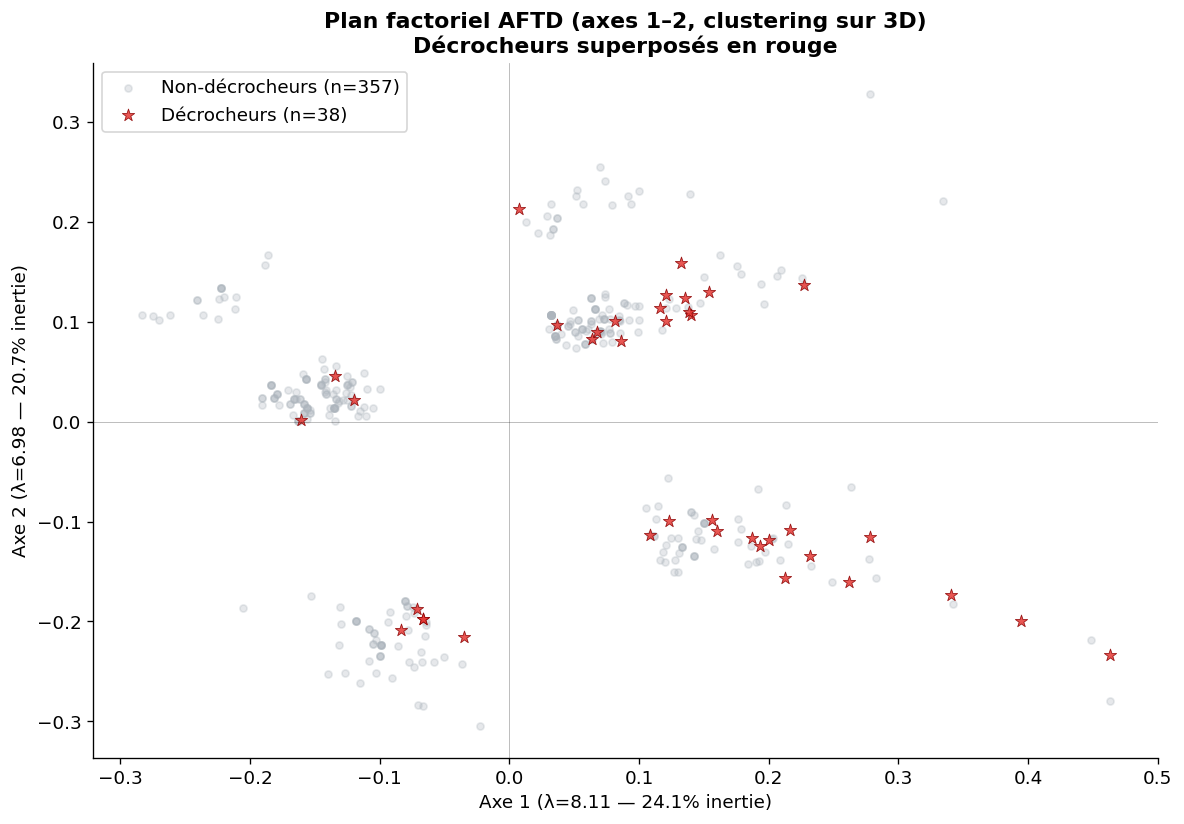

In [7]:
# Plan factoriel 1-2 avec décrocheurs superposés
dec_mask = mat_full['decrocheur'].values == 1

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(C_sel[~dec_mask,0], C_sel[~dec_mask,1], s=18, alpha=0.3,
           color='#adb5bd', label=f'Non-décrocheurs (n={(~dec_mask).sum()})', zorder=1)
ax.scatter(C_sel[dec_mask,0],  C_sel[dec_mask,1],  s=60, alpha=0.85,
           color=ROUGE, marker='*', edgecolors='darkred', lw=0.5,
           label=f'Décrocheurs (n={dec_mask.sum()})', zorder=2)
ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.axvline(0, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel(f'Axe 1 (λ={lam[0]:.2f} — {pct[0]:.1f}% inertie)')
ax.set_ylabel(f'Axe 2 (λ={lam[1]:.2f} — {pct[1]:.1f}% inertie)')
ax.set_title(f'Plan factoriel AFTD (axes 1–2, clustering sur {n_axes}D)\nDécrocheurs superposés en rouge',
             fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / '03_plan_factoriel.png', dpi=200, bbox_inches='tight')
plt.show()

In [8]:
# Nuage 3D interactif (Plotly) — axes 1–2–3 si n_axes >= 3
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _scene_axis_labels():
    return dict(
        xaxis_title=f'Axe 1 (λ={lam[0]:.2f}, {pct[0]:.1f}%)',
        yaxis_title=f'Axe 2 (λ={lam[1]:.2f}, {pct[1]:.1f}%)',
        zaxis_title=f'Axe 3 (λ={lam[2]:.2f}, {pct[2]:.1f}%)',
    )


def _tab10_rgb(k, n):
    r, g, b, _ = plt.cm.tab10(k / max(n - 1, 1))
    return f'rgb({int(255*r)},{int(255*g)},{int(255*b)})'


def add_cluster_traces_3d(fig, coords, labels, k, row, col):
    """Ajoute les traces cluster + décrocheurs sur un sous-graphique 3D Plotly."""
    for c in range(k):
        mask = labels == c
        fig.add_trace(
            go.Scatter3d(
                x=coords[mask, 0],
                y=coords[mask, 1],
                z=coords[mask, 2],
                mode='markers',
                marker=dict(size=4, color=_tab10_rgb(c, k), opacity=0.75),
                name=f'C{c} (n={mask.sum()})',
                legendgroup=f'c{c}',
            ),
            row=row,
            col=col,
        )
    fig.add_trace(
        go.Scatter3d(
            x=coords[dec_mask, 0],
            y=coords[dec_mask, 1],
            z=coords[dec_mask, 2],
            mode='markers',
            marker=dict(size=7, color='black', symbol='diamond'),
            name='Décrocheurs',
            legendgroup='dec',
        ),
        row=row,
        col=col,
    )


if SHOW_3D_SCATTER and n_axes >= 3:
    fig_drop = go.Figure()
    fig_drop.add_trace(
        go.Scatter3d(
            x=C_sel[~dec_mask, 0],
            y=C_sel[~dec_mask, 1],
            z=C_sel[~dec_mask, 2],
            mode='markers',
            marker=dict(size=3, color='#adb5bd', opacity=0.45),
            name=f'Non-décrocheurs (n={(~dec_mask).sum()})',
            hovertemplate='Axe1=%{x:.2f}<br>Axe2=%{y:.2f}<br>Axe3=%{z:.2f}<extra></extra>',
        )
    )
    fig_drop.add_trace(
        go.Scatter3d(
            x=C_sel[dec_mask, 0],
            y=C_sel[dec_mask, 1],
            z=C_sel[dec_mask, 2],
            mode='markers',
            marker=dict(size=6, color=ROUGE, symbol='diamond', opacity=0.9),
            name=f'Décrocheurs (n={dec_mask.sum()})',
            hovertemplate='Axe1=%{x:.2f}<br>Axe2=%{y:.2f}<br>Axe3=%{z:.2f}<extra>Décrocheur</extra>',
        )
    )
    fig_drop.update_layout(
        title=(
            f'Nuage AFTD 3D interactif (axes 1–3, clustering sur {n_axes}D)'
            '<br><sup>Rotation : clic gauche · Zoom : molette · Pan : clic droit</sup>'
        ),
        scene=_scene_axis_labels(),
        height=620,
        margin=dict(l=0, r=0, t=80, b=0),
    )
    fig_drop.show()
elif SHOW_3D_SCATTER:
    print(f'Nuage 3D ignoré : n_axes={n_axes} (requis ≥ 3).')

### 4.3 Contributions des variables aux axes conservés

Pour chaque axe retenu (1 à `n_axes`), la contribution d'une variable est le **cos²**
(r² de Pearson) entre ses valeurs et les coordonnées factorielles sur cet axe,
exprimé en **pourcentage** et normalisé à 100 % par axe.

Les barres bleues (resp. rouges) indiquent une corrélation positive (resp. négative)
avec l'axe.

Contributions des variables (%) — axes conservés


,Axe 1,Axe 2,Axe 3
failures,13.5,0.0,7.7
Medu,6.6,2.2,7.2
age,4.7,5.2,12.9
Walc,0.0,0.9,38.2
higher,13.6,0.3,4.5
paid,54.8,9.6,2.3
schoolsup,0.9,8.6,22.5
romantic,5.9,73.1,4.6


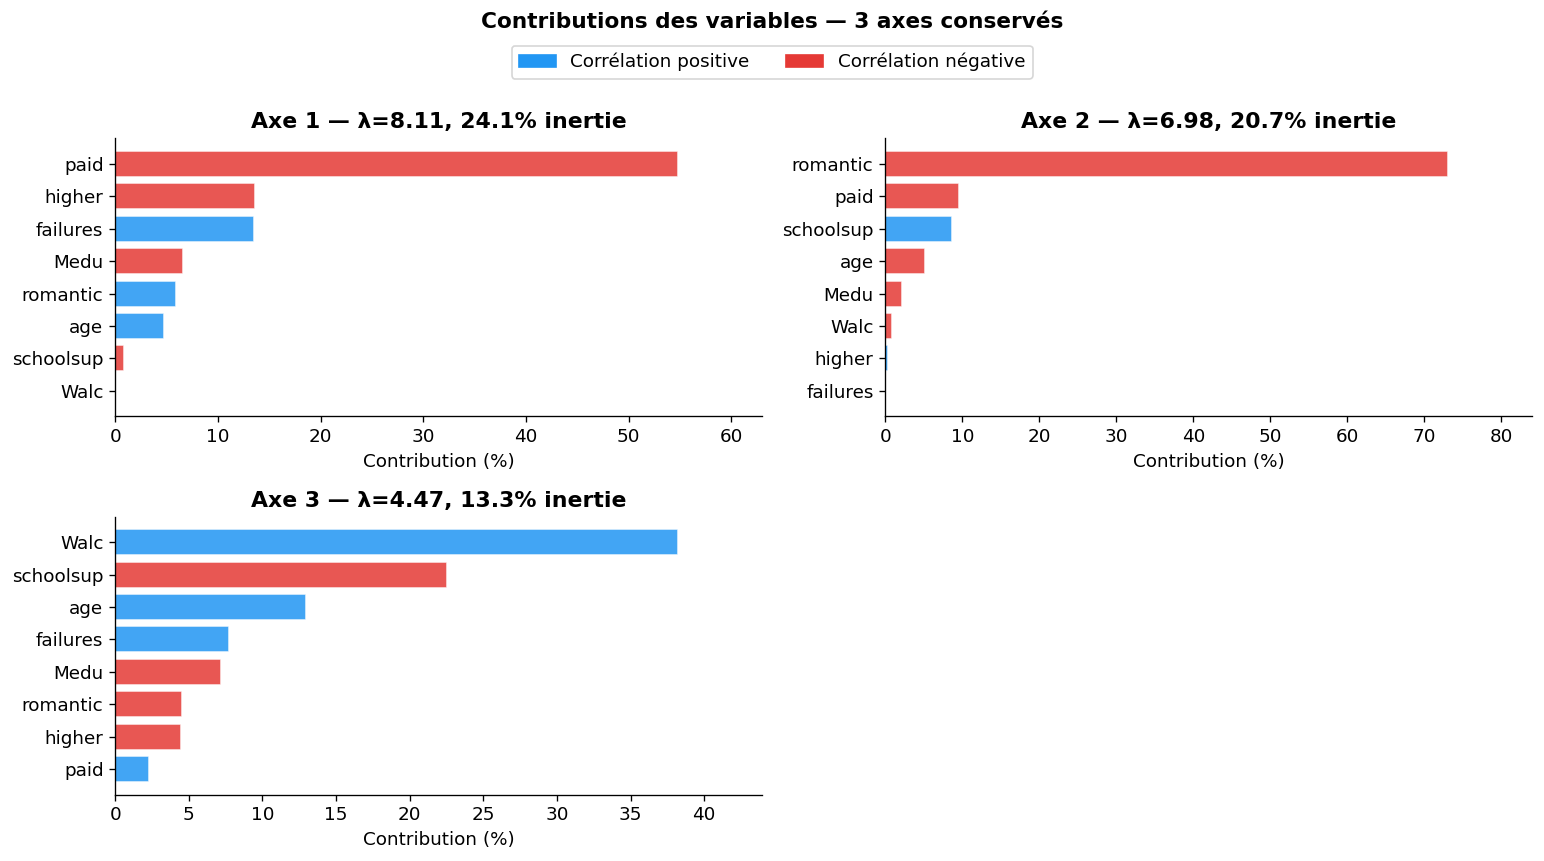

In [9]:
from matplotlib.patches import Patch

VARS_ALL = VARS_NUM + VARS_CAT


def _variable_values(var):
    if var in VARS_NUM:
        return df_num[var].to_numpy(dtype=float)
    return df_bin[var].to_numpy(dtype=float)


def compute_variable_contributions(coords, n_axes_retained):
    """cos² (r²) normalisé à 100 % par axe + corrélation signée."""
    cols = [f'Axe {k + 1}' for k in range(n_axes_retained)]
    corr = pd.DataFrame(index=VARS_ALL, columns=cols, dtype=float)
    contrib = pd.DataFrame(index=VARS_ALL, columns=cols, dtype=float)
    for k in range(n_axes_retained):
        axis = coords[:, k]
        col = cols[k]
        for var in VARS_ALL:
            r = np.corrcoef(_variable_values(var), axis)[0, 1]
            r = 0.0 if np.isnan(r) else float(r)
            corr.loc[var, col] = r
            contrib.loc[var, col] = r ** 2
        total = contrib[col].sum()
        if total > 0:
            contrib[col] = 100 * contrib[col] / total
    return contrib, corr


contrib_vars, corr_vars = compute_variable_contributions(C_sel, n_axes)
print('Contributions des variables (%) — axes conservés')
display(contrib_vars.round(1))

ncols = 2
nrows = int(np.ceil(n_axes / ncols))
fig, axes_grid = plt.subplots(nrows, ncols, figsize=(13, 3.4 * nrows))
axes_flat = np.atleast_1d(axes_grid).flatten()

for k in range(n_axes):
    ax = axes_flat[k]
    col = contrib_vars.columns[k]
    ordered = contrib_vars[col].sort_values(ascending=True)
    colors = [BLEU if corr_vars.loc[v, col] >= 0 else ROUGE for v in ordered.index]
    ax.barh(ordered.index, ordered.values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Contribution (%)')
    ax.set_title(
        f'{col} — λ={lam[k]:.2f}, {pct[k]:.1f}% inertie',
        fontweight='bold',
    )
    xmax = max(ordered.max() * 1.15, 5)
    ax.set_xlim(0, xmax)

for ax in axes_flat[n_axes:]:
    ax.set_visible(False)

fig.legend(
    handles=[
        Patch(color=BLEU, label='Corrélation positive'),
        Patch(color=ROUGE, label='Corrélation négative'),
    ],
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.5, 1.02),
)
plt.suptitle(
    f'Contributions des variables — {n_axes} axes conservés',
    fontweight='bold',
    fontsize=13,
    y=1.05,
)
plt.tight_layout()
fig.savefig(FIG_DIR / '03_contributions_variables.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 5. Classification Ascendante Hiérarchique — Méthode de Ward

### 5.1 Rappel théorique (cours Ch. 7, §5.5)

Ward fusionne à chaque étape les deux classes minimisant l'augmentation de l'inertie intra-classe :
$$D(A, B) = \frac{n_A \cdot n_B}{n_A + n_B} \cdot d^2(g_A, g_B)$$

Ward est appliqué ici sur les **coordonnées factorielles** (euclidiennes par construction).
Le cours (§5.7) recommande d'utiliser conjointement une méthode de réduction de dimension
avant la classification, ici l'AFTD.

Le choix de K repose sur **deux critères conjoints** :
1. La **méthode du coude sur les sauts d'inertie** (cours §4.3) — saut le plus grand
   à la coupure K→K-1
2. L'**interprétabilité des profils** — un K trop grand produit des clusters non
   distinguables sur les variables de sélection

In [10]:
# Ward sur les coordonnées factorielles (euclidiennes par construction)
Z_ward = linkage(C_sel, method='ward')

# Sauts d'inertie pour explorer K (cours §4.3)
fusion_dists = Z_ward[-15:, 2][::-1]
sauts_all = [fusion_dists[i] - fusion_dists[i+1]
             for i in range(len(fusion_dists)-1)]

print("Sauts d'inertie (distances de fusion Ward)")
print(f"{'K':>4} {'Dist. fusion':>14} {'Saut →K-1':>12}")
print("-" * 34)
for i in range(len(sauts_all)):
    K_cut = i + 2
    saut = sauts_all[i]
    marq = ""
    if K_cut >= 3:
        # marqué plus tard sur le graphique avec K_MIN
        pass
    print(f"{K_cut:>4} {fusion_dists[i]:>14.4f} {saut:>12.4f}{marq}")

Sauts d'inertie (distances de fusion Ward)
   K   Dist. fusion    Saut →K-1
----------------------------------
   2         3.5075       0.5132
   3         2.9944       0.6720
   4         2.3223       0.6738
   5         1.6485       0.4551
   6         1.1934       0.0444
   7         1.1491       0.0555
   8         1.0936       0.2707
   9         0.8229       0.0169
  10         0.8060       0.0091
  11         0.7968       0.0796
  12         0.7172       0.1971
  13         0.5201       0.0388
  14         0.4814       0.0059
  15         0.4755       0.0541


**Lecture des sauts d'inertie :**

Le tableau ci-dessus liste les sauts d'inertie Ward pour chaque coupure K → K−1. Les deux sauts les plus importants (K ≥ 3) sont quasi-équivalents : 0,672 pour K=3 et 0,674 pour K=4. Le saut maximal (K ≥ 3) fournit la suggestion CAH **K = 4**, reportée sur le dendrogramme en pointillés rouges.

Le K retenu pour la suite est choisi automatiquement en section 6 via K-means (coude + silhouette, avec K ≥ 3).

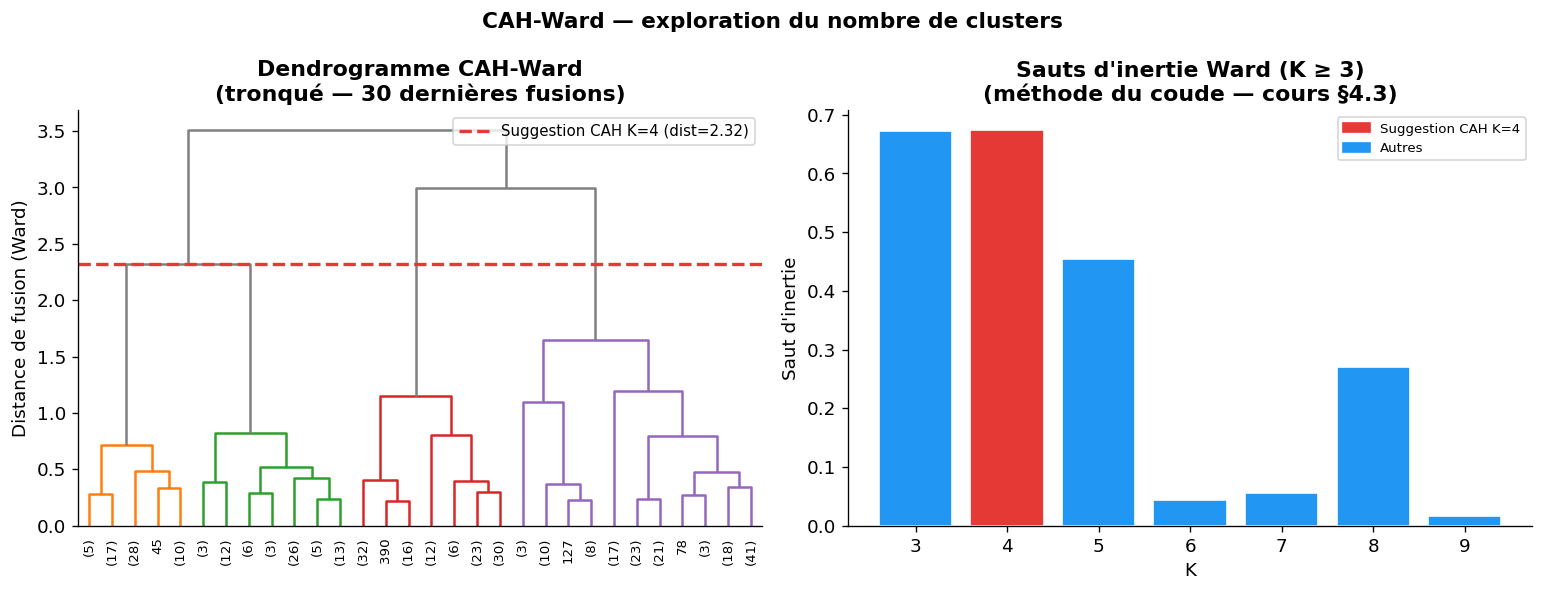

Suggestion CAH (saut maximal, K ≥ 3) : K = 4


In [11]:
# Suggestion CAH : saut maximal pour K >= K_MIN (affichée sur le dendrogramme)
K_MIN, K_MAX = 3, 10

fds_all = Z_ward[-(K_MAX - 1):, 2][::-1]
sauts_all_k = [fds_all[i] - fds_all[i + 1] for i in range(len(fds_all) - 1)]
Ks_ward = list(range(2, len(sauts_all_k) + 2))
sauts_kmin = [(K, s) for K, s in zip(Ks_ward, sauts_all_k) if K >= K_MIN]
K_ward_suggest = max(sauts_kmin, key=lambda x: x[1])[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
threshold_k = Z_ward[-(K_ward_suggest - 1), 2]
dendrogram(Z_ward, ax=ax1, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=threshold_k,
           above_threshold_color='gray')
ax1.axhline(threshold_k, color=ROUGE, lw=2, ls='--',
            label=f'Suggestion CAH K={K_ward_suggest} (dist={threshold_k:.2f})')
ax1.set_title('Dendrogramme CAH-Ward\n(tronqué — 30 dernières fusions)', fontweight='bold')
ax1.set_ylabel('Distance de fusion (Ward)')
ax1.legend(fontsize=9)

ax2 = axes[1]
Ks_plot = [K for K in Ks_ward if K_MIN <= K <= K_MAX]
sauts_plot = [sauts_all_k[K - 2] for K in Ks_plot]
colors_bar = [ROUGE if K == K_ward_suggest else BLEU for K in Ks_plot]
ax2.bar(Ks_plot, sauts_plot, color=colors_bar, edgecolor='white')
ax2.set_xlabel('K')
ax2.set_ylabel("Saut d'inertie")
ax2.set_title("Sauts d'inertie Ward (K ≥ 3)\n(méthode du coude — cours §4.3)", fontweight='bold')
ax2.set_xticks(Ks_plot)
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color=ROUGE, label=f'Suggestion CAH K={K_ward_suggest}'),
    Patch(color=BLEU, label='Autres'),
], fontsize=8)

plt.suptitle("CAH-Ward — exploration du nombre de clusters", fontweight='bold', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / '03_cah_dendrogramme.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Suggestion CAH (saut maximal, K ≥ {K_MIN}) : K = {K_ward_suggest}")

### 5.3 K retenu — choix automatique (section 6)

La partition CAH-Ward finale et la comparaison ARI utilisent le **K optimal K-means**
déterminé en section 6 (coude sur $I_W$ + silhouette, avec **K ≥ 3**).

---
## 6. Méthode des K-means (centres mobiles)

### 6.1 Rappel théorique (cours Ch. 7, §6.1)

La méthode des centres mobiles minimise $I_W(P)$ par optimisation alternée : affectation au centre le plus proche, puis mise à jour des centres de gravité. Le cours note que l'algorithme est **sensible à l'initialisation** (risque d'optimum local). On utilise `k-means++` — initialisation améliorée cohérente avec cette précaution du cours.

K-means est appliqué sur les **mêmes coordonnées factorielles** que la CAH pour permettre la comparaison ARI à iso-représentation.

K suggéré (coude)     : 5
K suggéré (silhouette): 4
→ K retenu            : 4  (K ≥ 3)


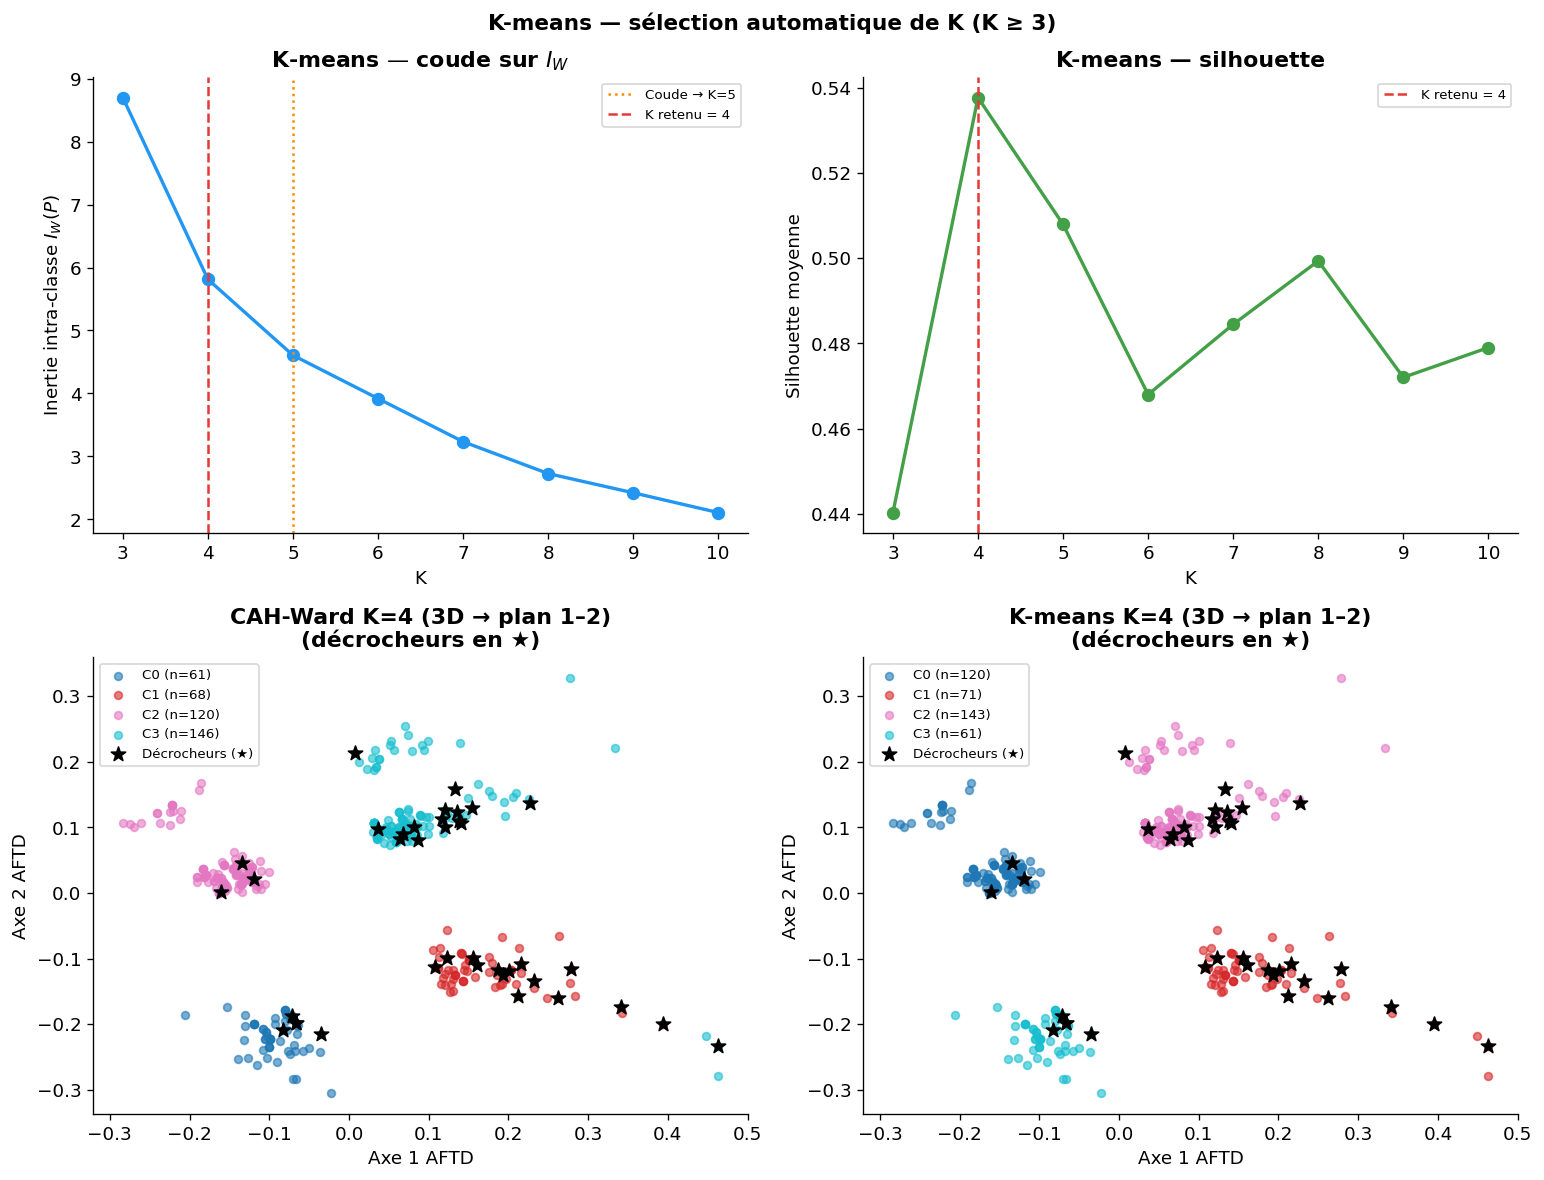


Partition CAH-Ward K=4 :
  C0 : n=61, décrocheurs=5 (8.2%)
  C1 : n=68, décrocheurs=14 (20.6%)
  C2 : n=120, décrocheurs=3 (2.5%)
  C3 : n=146, décrocheurs=16 (11.0%)

Partition K-means K=4 :
  C0 : n=120, décrocheurs=3 (2.5%)
  C1 : n=71, décrocheurs=15 (21.1%)
  C2 : n=143, décrocheurs=15 (10.5%)
  C3 : n=61, décrocheurs=5 (8.2%)


In [12]:
K_MIN, K_MAX = 3, 10  # K ≥ 3 imposé

def suggest_k_elbow(ks, inertias):
    """Point de coude via distance maximale à la corde (K ≥ 3)."""
    ks = np.asarray(ks, dtype=float)
    ys = np.asarray(inertias, dtype=float)
    if len(ks) < 3:
        return int(ks[0])
    p1 = np.array([ks[0], ys[0]])
    p2 = np.array([ks[-1], ys[-1]])
    line = p2 - p1
    line_norm = line / (np.linalg.norm(line) + 1e-12)
    dists = [abs(np.cross(line_norm, np.array([ks[i], ys[i]]) - p1)) for i in range(len(ks))]
    return int(ks[int(np.argmax(dists))])


def plot_clusters_2d(ax, coords, labels, k, title):
    colors = plt.cm.tab10(np.linspace(0, 0.9, max(k, 1)))
    for c in range(k):
        mask = labels == c
        ax.scatter(coords[mask, 0], coords[mask, 1], s=22, alpha=0.6,
                   color=colors[c], label=f'C{c} (n={mask.sum()})')
    ax.scatter(coords[dec_mask, 0], coords[dec_mask, 1], s=80, marker='*',
               color='black', zorder=3, label='Décrocheurs (★)')
    ax.set_xlabel('Axe 1 AFTD')
    ax.set_ylabel('Axe 2 AFTD')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)


# Métriques K-means pour K ∈ [K_MIN, K_MAX]
k_range = range(K_MIN, K_MAX + 1)
metrics_km = []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=RANDOM_STATE)
    labels_tmp = km.fit_predict(C_sel)
    metrics_km.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(C_sel, labels_tmp),
    })
df_km = pd.DataFrame(metrics_km)

K_elbow = suggest_k_elbow(df_km['k'].values, df_km['inertia'].values)
K_sil = int(df_km.loc[df_km['silhouette'].idxmax(), 'k'])
K = K_sil  # K retenu : silhouette max (K ≥ K_MIN)

print(f"K suggéré (coude)     : {K_elbow}")
print(f"K suggéré (silhouette): {K_sil}")
print(f"→ K retenu            : {K}  (K ≥ {K_MIN})")

# K-means final
km_final = KMeans(n_clusters=K, init='k-means++', n_init=50, random_state=RANDOM_STATE)
labels_km = km_final.fit_predict(C_sel)

# CAH-Ward au même K
labels_cah = fcluster(Z_ward, K, criterion='maxclust') - 1

# ── Export rapport : coude + silhouette (annexe) ──
fig_k_sel, axes_k = plt.subplots(1, 2, figsize=(11, 4))
ax = axes_k[0]
ax.plot(df_km['k'], df_km['inertia'], 'o-', color=BLEU, lw=2, ms=7)
ax.axvline(K_elbow, color=ORANGE, lw=1.5, ls=':', label=f'Coude → K={K_elbow}')
ax.axvline(K, color=ROUGE, lw=1.5, ls='--', label=f'K retenu = {K}')
ax.set_xlabel('K')
ax.set_ylabel('Inertie intra-classe $I_W(P)$')
ax.set_title('K-means — coude sur $I_W$', fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend(fontsize=8)
ax = axes_k[1]
ax.plot(df_km['k'], df_km['silhouette'], 'o-', color=VERT, lw=2, ms=7)
ax.axvline(K, color=ROUGE, lw=1.5, ls='--', label=f'K retenu = {K}')
ax.set_xlabel('K')
ax.set_ylabel('Silhouette moyenne')
ax.set_title('K-means — silhouette', fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend(fontsize=8)
fig_k_sel.suptitle(f'Sélection de $K$ (K ≥ {K_MIN})', fontweight='bold', fontsize=12)
fig_k_sel.tight_layout()
fig_k_sel.savefig(FIG_DIR / '03_kmeans_coude_silhouette.png', dpi=200, bbox_inches='tight')
plt.close(fig_k_sel)

# ── Export rapport : plan factoriel coloré par cluster (§3.3) ──
fig_clust, ax_clust = plt.subplots(figsize=(10, 7))
plot_clusters_2d(ax_clust, C_sel, labels_km, K,
                 f'K-means $K={K}$ — plan factoriel AFTD (axes 1–2)\n(décrocheurs en ★)')
fig_clust.tight_layout()
fig_clust.savefig(FIG_DIR / '03_plan_factoriel_clusters.png', dpi=200, bbox_inches='tight')
plt.close(fig_clust)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Coude
ax = axes[0, 0]
ax.plot(df_km['k'], df_km['inertia'], 'o-', color=BLEU, lw=2, ms=7)
ax.axvline(K_elbow, color=ORANGE, lw=1.5, ls=':', label=f'Coude → K={K_elbow}')
ax.axvline(K, color=ROUGE, lw=1.5, ls='--', label=f'K retenu = {K}')
ax.set_xlabel('K')
ax.set_ylabel('Inertie intra-classe $I_W(P)$')
ax.set_title('K-means — coude sur $I_W$', fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend(fontsize=8)

# Silhouette
ax = axes[0, 1]
ax.plot(df_km['k'], df_km['silhouette'], 'o-', color=VERT, lw=2, ms=7)
ax.axvline(K, color=ROUGE, lw=1.5, ls='--', label=f'K retenu = {K}')
ax.set_xlabel('K')
ax.set_ylabel('Silhouette moyenne')
ax.set_title('K-means — silhouette', fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend(fontsize=8)

# Plans factoriels 2D
plot_clusters_2d(axes[1, 0], C_sel, labels_cah, K,
                 f'CAH-Ward K={K} ({n_axes}D → plan 1–2)\n(décrocheurs en ★)')
plot_clusters_2d(axes[1, 1], C_sel, labels_km, K,
                 f'K-means K={K} ({n_axes}D → plan 1–2)\n(décrocheurs en ★)')

plt.suptitle(f'K-means — sélection automatique de K (K ≥ {K_MIN})', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

if SHOW_3D_SCATTER and n_axes >= 3:
    fig_clust = make_subplots(
        rows=1,
        cols=2,
        specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
        subplot_titles=(
            f'CAH-Ward K={K} ({n_axes}D → axes 1–2–3)',
            f'K-means K={K} ({n_axes}D → axes 1–2–3)',
        ),
    )
    add_cluster_traces_3d(fig_clust, C_sel, labels_cah, K, row=1, col=1)
    add_cluster_traces_3d(fig_clust, C_sel, labels_km, K, row=1, col=2)
    scene_kw = _scene_axis_labels()
    fig_clust.update_layout(
        title='Partitions — vue 3D interactive (Plotly)',
        height=620,
        margin=dict(l=0, r=0, t=90, b=0),
    )
    fig_clust.update_scenes(scene_kw, row=1, col=1)
    fig_clust.update_scenes(scene_kw, row=1, col=2)
    fig_clust.show()

print(f"\nPartition CAH-Ward K={K} :")
for k in range(K):
    mask = labels_cah == k
    n_k = mask.sum()
    n_d = ((labels_cah == k) & (mat_full['decrocheur'] == 1)).sum()
    print(f"  C{k} : n={n_k}, décrocheurs={n_d} ({100 * n_d / n_k:.1f}%)")

print(f"\nPartition K-means K={K} :")
for k in range(K):
    mask = labels_km == k
    n_k = mask.sum()
    n_d = ((labels_km == k) & (mat_full['decrocheur'] == 1)).sum()
    print(f"  C{k} : n={n_k}, décrocheurs={n_d} ({100 * n_d / n_k:.1f}%)")

Le K retenu est **K = 4**, maximisant la silhouette moyenne sur [3, 10] (avec K ≥ 3). Le coude suggérait K = 5 et la CAH K = 4 — la silhouette tranche en faveur de K = 4. Les deux partitions (CAH-Ward et K-means) au même K sont comparées visuellement sur le plan 1–2.

Taux de décrochage par cluster (K-means) :
- **C0** (n=120) : 2,5 % — profil à faible risque
- **C1** (n=71) : 21,1 % — profil à risque élevé
- **C2** (n=143) : 10,5 % — profil intermédiaire
- **C3** (n=61) : 8,2 % — profil intermédiaire-bas

---
## 7. Comparaison des partitions — Indice de Rand Ajusté

### 7.1 Rappel théorique (cours Ch. 7, §7 — Définition 16)

L'ARI compare deux partitions en corrigeant l'espérance de l'indice de Rand sous l'hypothèse d'indépendance. ARI=1 si P=Q ; ARI≈0 si indépendant. Un ARI élevé entre deux méthodes de **natures fondamentalement différentes** (CAH hiérarchique vs K-means itératif) est un **argument de robustesse fort** : la structure trouvée ne dépend pas de l'algorithme utilisé.

In [13]:
ari = adjusted_rand_score(labels_cah, labels_km)

conf = pd.crosstab(
    pd.Series(labels_cah, name='CAH-Ward'),
    pd.Series(labels_km,  name='K-means'),
    rownames=['CAH-Ward'],
    colnames=['K-means'],
    margins=True,
    margins_name='Total'
)
# Renommer les index pour plus de clarté
conf.index   = [f'C{i}' if i != 'Total' else 'Total' for i in conf.index]
conf.columns = [f'C{j}' if j != 'Total' else 'Total' for j in conf.columns]

print(f"ARI (CAH-Ward vs K-means) = {ari:.4f}")
print()
print("Matrice de contingence :")
print(conf.to_string())
print()
if ari > 0.99:
    print("→ ARI = 1,000 : les deux méthodes produisent exactement la même partition.")
    print(f"  La structure K={K} est robuste — indépendante de l'algorithme utilisé.")
else:
    print(f"→ ARI = {ari:.3f} : convergence {'forte' if ari > 0.80 else 'modérée'} entre les deux méthodes.")

ARI (CAH-Ward vs K-means) = 0.9798

Matrice de contingence :
        C0  C1   C2  C3  Total
C0       0   0    0  61     61
C1       0  68    0   0     68
C2     120   0    0   0    120
C3       0   3  143   0    146
Total  120  71  143  61    395

→ ARI = 0.980 : convergence forte entre les deux méthodes.


## 8. Caractérisation descriptive des profils

Les clusters sont caractérisés sur les 8 variables ayant servi au clustering (section 2), sur l'ensemble du jeu (395 élèves). Le taux de décrochage est affiché à titre indicatif dans les titres des graphes — son interprétation statistique formelle est réalisée en section 10 (tests Kruskal-Wallis et χ² avec correction de Bonferroni).

Profil moyen par cluster (K-means, K=4)
           n  failures  Medu    age  Walc  higher  paid  schoolsup  romantic
cluster                                                                     
0        120      0.16  2.88  16.48  2.38    1.00   1.0       0.15       0.0
1         71      0.61  2.61  17.01  2.18    0.86   0.0       0.11       1.0
2        143      0.39  2.58  16.60  2.24    0.94   0.0       0.15       0.0
3         61      0.23  3.05  16.97  2.38    0.98   1.0       0.07       1.0


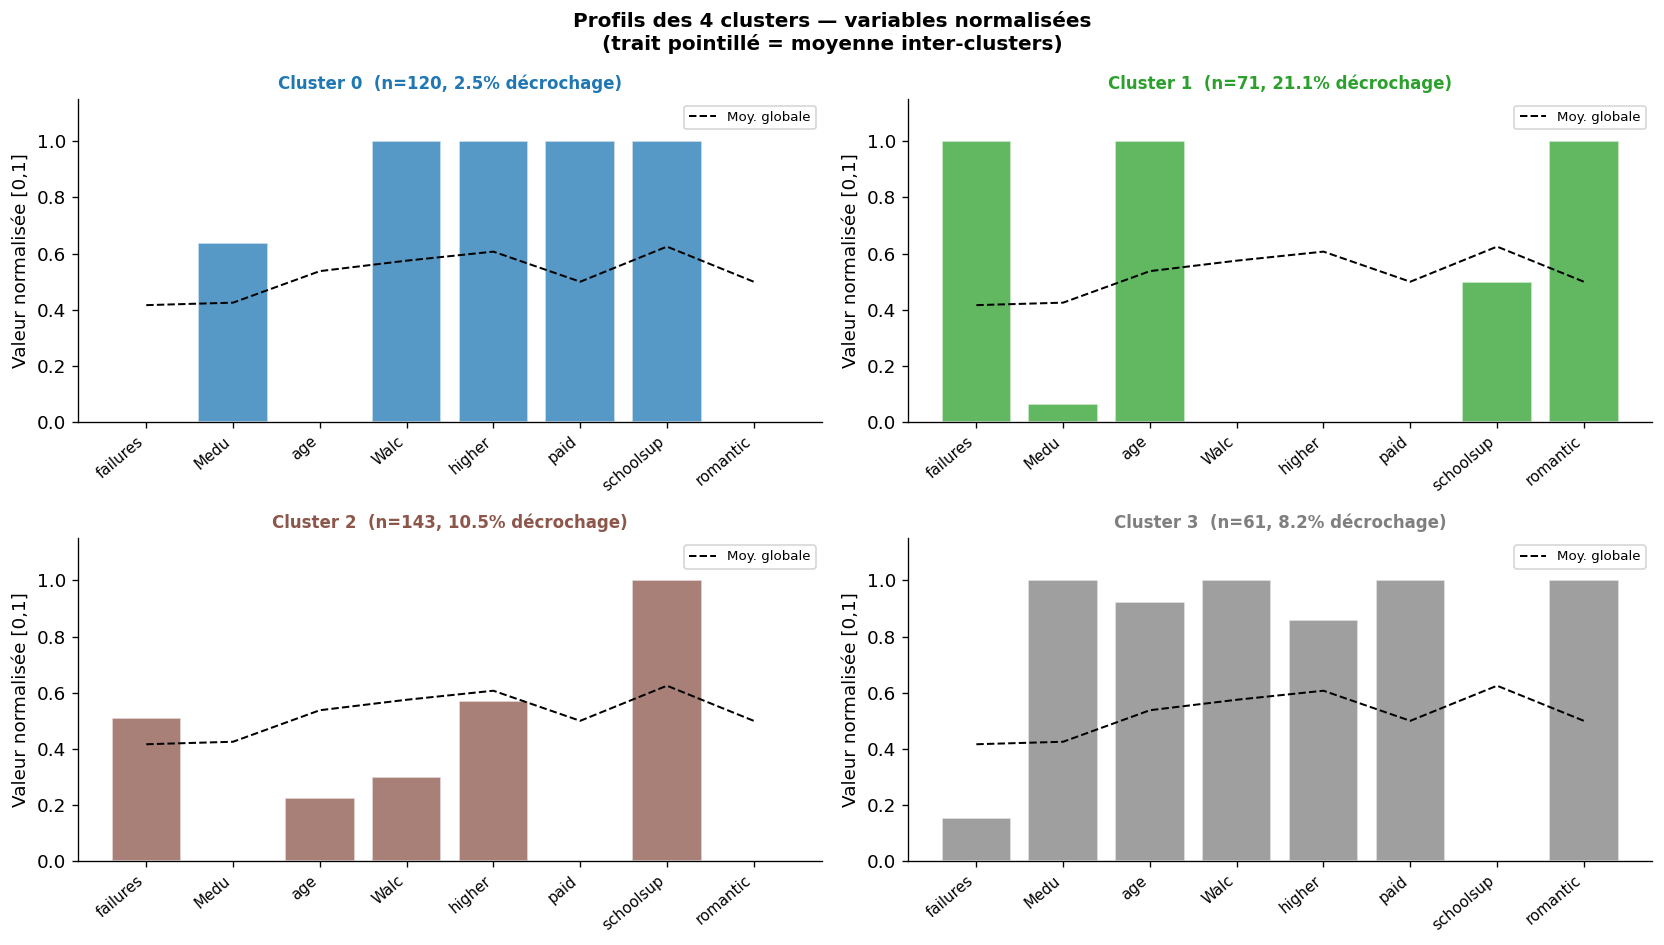

In [14]:
mat_full['cluster'] = labels_km

# Profil moyen par cluster
profil = mat_full.groupby('cluster')[VARS_NUM].mean().round(2)
for v in VARS_CAT:
    profil[v] = (mat_full.groupby('cluster')[v]
                    .apply(lambda x: (x == 'yes').mean())).round(2)
profil['n'] = mat_full.groupby('cluster')['decrocheur'].count()
profil['taux_dec'] = (mat_full.groupby('cluster')['decrocheur'].mean() * 100).round(1)

cols_show = ['n', 'failures', 'Medu', 'age', 'Walc', 'higher', 'paid', 'schoolsup', 'romantic']
print(f"Profil moyen par cluster (K-means, K={K})")
print(profil[cols_show].to_string())

vars_show  = VARS_NUM + VARS_CAT
profil_num = profil[vars_show].copy()
maxv = profil_num.max().values
minv = profil_num.min().values

n_rows = (K + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for k, ax in enumerate(axes[:K]):
    vals_k = profil_num.loc[k].values.astype(float)
    glob   = profil_num.mean().values
    vals_n = (vals_k - minv) / (maxv - minv + 1e-9)
    glob_n = (glob   - minv) / (maxv - minv + 1e-9)
    x = np.arange(len(vars_show))
    ax.bar(x, vals_n, color=plt.cm.tab10(k / max(K, 1)), alpha=0.75, edgecolor='white')
    ax.plot(x, glob_n, 'k--', lw=1.2, label='Moy. globale')
    ax.set_xticks(x)
    ax.set_xticklabels(vars_show, rotation=40, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    n_k   = int(profil.loc[k, 'n'])
    taux  = profil.loc[k, 'taux_dec']
    ax.set_title(f'Cluster {k}  (n={n_k}, {taux:.1f}% décrochage)',
                 fontsize=10, fontweight='bold', color=plt.cm.tab10(k / max(K, 1)))
    ax.set_ylabel('Valeur normalisée [0,1]')
    ax.legend(fontsize=8)

plt.suptitle(f'Profils des {K} clusters — variables normalisées\n'
             '(trait pointillé = moyenne inter-clusters)',
             fontweight='bold', fontsize=12)
for ax in axes[K:]:
    ax.set_visible(False)
plt.tight_layout()
fig.savefig(FIG_DIR / '03_profils_clusters.png', dpi=200, bbox_inches='tight')
plt.show()


**Lecture des 4 profils :**

Le tableau des moyennes et le graphique normalisé permettent de caractériser les 4 clusters :

- **C0 (n=120, 2,5 % décrochage)** — élèves ayant suivi des cours particuliers (`paid=1,0`), aspirant aux études supérieures (`higher=1,0`), sans vie romantique (`romantic=0`). Profil le plus protégé, taux de décrochage le plus bas.
- **C1 (n=71, 21,1 % décrochage)** — taux d'échecs antérieurs le plus élevé (`failures=0,61`), pas de cours particuliers (`paid=0`), vie romantique (`romantic=1`). C'est le **profil à risque dominant**, qui cumule les facteurs de vulnérabilité scolaire et familiale.
- **C2 (n=143, 10,5 % décrochage)** — le cluster le plus grand, caractérisé par une absence de cours particuliers (`paid=0`) sans vie romantique (`romantic=0`). Profil intermédiaire.
- **C3 (n=61, 8,2 % décrochage)** — niveau d'éducation maternelle le plus élevé (`Medu=3,05`), cours particuliers (`paid=1`), vie romantique (`romantic=1`). Malgré le soutien familial, le taux de décrochage reste modéré.

Cette lecture descriptive est approfondie statistiquement en section 10.

---
## 9. Synthèse et articulation avec les notebooks 02 et 03

### 9.1 Résultats clés

### 9.1 Résultats clés

Les indicateurs ci-dessous dépendent de `VARIANCE_THRESHOLD` et du K choisi automatiquement
en section 6 (silhouette max, K ≥ 3). Exécuter la cellule ci-dessous pour le run courant.

| Indicateur | Description |
|------------|-------------|
| Seuil variance AFTD | Paramètre `VARIANCE_THRESHOLD` (section 4.1b) |
| Nuage 3D | `SHOW_3D_SCATTER` — Plotly interactif, axes 1–2–3 si `n_axes ≥ 3` |
| Contributions variables | cos² (r²) normalisé — un graphique par axe conservé (§4.3) |
| Axes retenus | `n_axes` — dérivé automatiquement du seuil |
| K retenu | `K` — silhouette max sur `[K_MIN, K_MAX]` |
| ARI | Concordance CAH-Ward vs K-means au même K |

In [15]:
print(f"Seuil variance AFTD     : {VARIANCE_THRESHOLD:.0%}")
print(f"Nuage 3D (Plotly)       : {SHOW_3D_SCATTER and n_axes >= 3}  (SHOW_3D_SCATTER={SHOW_3D_SCATTER}, n_axes={n_axes})")
print(f"Axes retenus            : {n_axes}")
print(f"Inertie cumulée         : {pct[:n_axes].sum():.1f} %")
print(f"K retenu (K-means)      : {K}  (coude={K_elbow}, silhouette={K_sil})")
print(f"Shepard r (dim={n_axes})  : {r_shep:.3f}")
print(f"Shepard RMSE relatif    : {100*rmse_shep/d_init.max():.1f} % de d_max")
print(f"Val. propres négatives  : {(~pos).sum()} / {n}")
print(f"ARI (CAH vs K-means)    : {ari:.3f}")

Seuil variance AFTD     : 58%
Nuage 3D (Plotly)       : True  (SHOW_3D_SCATTER=True, n_axes=3)
Axes retenus            : 3
Inertie cumulée         : 58.1 %
K retenu (K-means)      : 4  (coude=5, silhouette=4)
Shepard r (dim=3)  : 0.901
Shepard RMSE relatif    : 6.5 % de d_max
Val. propres négatives  : 375 / 395
ARI (CAH vs K-means)    : 0.980


### 9.2 Bilan et enchaînement vers la validation

**Acquis :** des profils structurés émergent des seules variables socio-comportementales disponibles en début d'année. Avec un seuil AFTD de **58 %** (3 axes retenus, Shepard r = 0,901), K-means et CAH-Ward convergent vers la même partition **K = 4** (ARI = 0,980). Le cluster C1 concentre 21,1 % de décrocheurs — presque 10 fois le taux du cluster C0 (2,5 %).

**Limites de l'étape descriptive :** un taux élevé dans un cluster ne suffit pas à conclure. Les sections 10 à 13 approfondissent la validation :
- §10 : significativité statistique des différences inter-clusters (Bonferroni sur 6 paires)
- §11 : stabilité par bootstrap (AFTD recalculée avec le même seuil de 58 %)
- §12–13 : validité externe (notes G1/G2/G3, variables non utilisées)

Le notebook 02 traite quant à lui la prédiction supervisée du décrochage à partir de G1, G2, G3 — question distincte de l'identification de profils.


---
## 10. Validation statistique : les profils existent-ils vraiment ?

Les différences visuelles entre clusters (section 8) ne suffisent pas à prouver que les
profils sont statistiquement distincts : avec 8 variables et K groupes, certaines
différences observées peuvent être dues au hasard. Des **tests d'hypothèses** avec
**correction de Bonferroni** pour les comparaisons multiples (`N_PAIRS` paires)
sont nécessaires pour identifier quelles variables discriminent réellement les profils.


In [16]:
# ── Helpers tests statistiques ──
CLUSTER_PAIRS = list(combinations(range(K), 2))
N_PAIRS = len(CLUSTER_PAIRS)
ALPHA = 0.05
ALPHA_BONF = ALPHA / N_PAIRS


def eta_squared_kruskal(H, n, k):
    return (H - k + 1) / (n - k)


def interpret_eta2(e):
    if e < 0.01:
        return 'faible'
    if e < 0.06:
        return 'modéré'
    return 'fort'


def cramers_v(chi2, n, r, c):
    return np.sqrt(chi2 / (n * min(r - 1, c - 1))) if n > 0 else 0.0


def interpret_cramers(v):
    if v < 0.1:
        return 'faible'
    if v < 0.3:
        return 'modéré'
    return 'fort'


def pairwise_mannwhitney(values, labels, pairs=CLUSTER_PAIRS):
    """Retourne True si au moins une paire est significative après Bonferroni."""
    sig = False
    for c0, c1 in pairs:
        g0 = values[labels == c0]
        g1 = values[labels == c1]
        if len(g0) < 2 or len(g1) < 2:
            continue
        _, p = mannwhitneyu(g0, g1, alternative='two-sided')
        if p < ALPHA_BONF:
            sig = True
    return sig


In [17]:
# ── Tests globaux et post-hoc ──
labels = labels_km
rows = []

for var in VARS_NUM:
    groups = [mat_full.loc[labels == k, var].values for k in range(K)]
    H, p_glob = kruskal(*groups)
    eta2 = eta_squared_kruskal(H, n, K)
    sig = pairwise_mannwhitney(mat_full[var].values, labels)
    rows.append({
        'variable': var, 'type': 'numérique',
        'p_globale': p_glob, 'significatif': 'oui' if sig else 'non',
        'taille_effet': round(eta2, 4),
        'interprétation': interpret_eta2(eta2),
    })

for var in VARS_CAT:
    ct = pd.crosstab(mat_full['cluster'], mat_full[var])
    chi2, p_glob, _, _ = chi2_contingency(ct)
    v_cram = cramers_v(chi2, ct.values.sum(), *ct.shape)
    sig = False
    for c0, c1 in CLUSTER_PAIRS:
        sub = ct.loc[[c0, c1]]
        if sub.values.sum() == 0:
            continue
        try:
            _, p_pair, _, _ = chi2_contingency(sub)
        except ValueError:
            if sub.shape == (2, 2):
                _, p_pair = fisher_exact(sub.values)
            else:
                continue
        if p_pair < ALPHA_BONF:
            sig = True
    rows.append({
        'variable': var, 'type': 'catégorielle',
        'p_globale': p_glob, 'significatif': 'oui' if sig else 'non',
        'taille_effet': round(v_cram, 4),
        'interprétation': interpret_cramers(v_cram),
    })

tab_valid = pd.DataFrame(rows)
tab_valid['p_globale'] = tab_valid['p_globale'].round(4)
tab_valid = tab_valid.sort_values('p_globale')
print("Tableau récapitulatif — discrimination inter-clusters (Bonferroni α/6 = "
      f"{ALPHA_BONF:.4f})")
display(tab_valid)


Tableau récapitulatif — discrimination inter-clusters (Bonferroni α/6 = 0.0083)


,variable,type,p_globale,significatif,taille_effet,interprétation
7,romantic,catégorielle,0.0000,oui,1.0000,fort
5,paid,catégorielle,0.0000,oui,1.0000,fort
0,failures,numérique,0.0001,oui,0.0465,modéré
4,higher,catégorielle,0.0001,oui,0.2270,modéré
2,age,numérique,0.0093,non,0.0217,modéré
1,Medu,numérique,0.0111,oui,0.0208,modéré
6,schoolsup,catégorielle,0.3580,non,0.0904,faible
3,Walc,numérique,0.4794,non,-0.0013,faible


**Conclusion — validation statistique**

Le tableau récapitulatif liste pour chaque variable la p-valeur globale (Kruskal-Wallis pour les variables numériques, χ² pour les variables catégorielles), la significativité post-hoc après correction de Bonferroni sur **6 paires** (α/6 = 0,0083) et la taille d'effet. Les variables marquées « oui » discriminent réellement les 4 profils ; les autres contribuent principalement à la géométrie globale de la distance mixte sans séparer les clusters de façon statistiquement fiable.


**Conclusion — stabilité**

Le bootstrap recalcule l'AFTD à chaque itération avec le seuil de 58 % (3 axes) et applique K-means avec K = 4 clusters. Les résultats sont stables : **médiane ARI = 1,000**, moyenne = 1,000, P5 = 1,000, P95 = 1,000. La partition K = 4 se reproduit à l'identique sur 100 % des sous-échantillons de 80 % des données. C'est un argument de robustesse maximal : la structure n'est pas un artefact de l'échantillon complet.

---
## 11. Validation externe par les trajectoires de notes

La **validation externe** utilise des variables **absentes du clustering** pour
vérifier que les profils capturent une réalité scolaire. Si les clusters se
distinguent sur G1, G2 et G3 — qu'ils n'ont jamais vus — c'est une preuve de
validité indépendante de la partition comportementale.


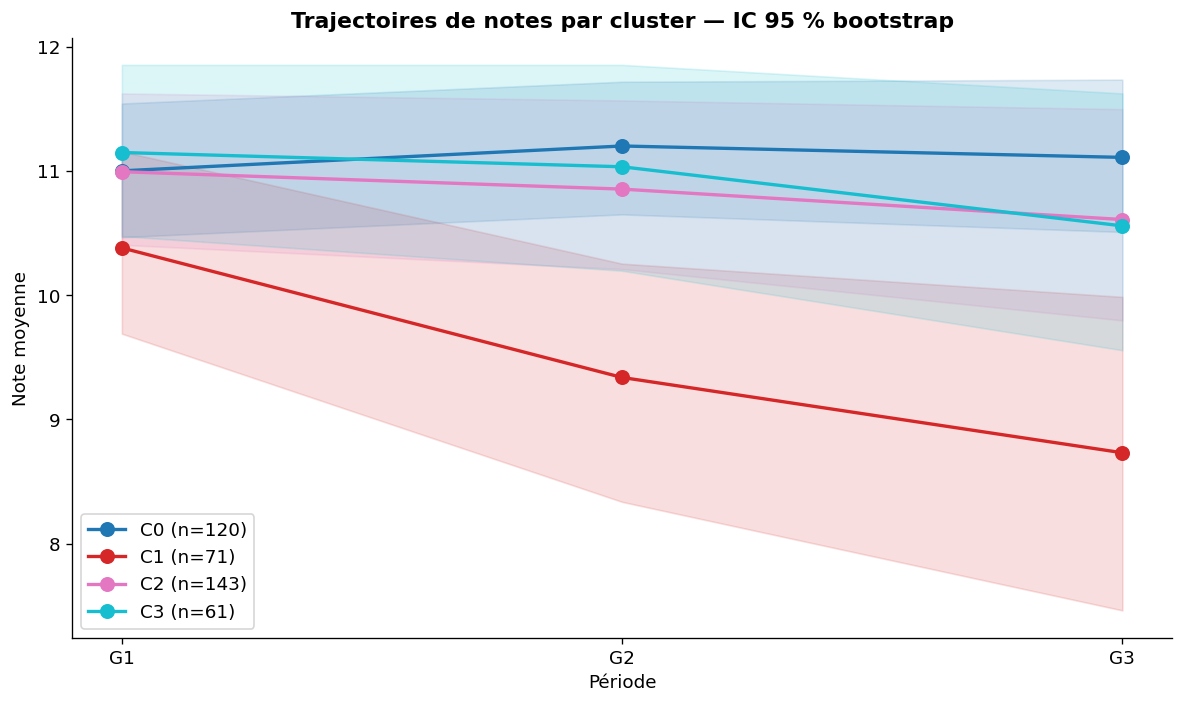

In [18]:
# ── Moyennes et IC 95 % bootstrap (1000 itér.) par cluster ──
N_BOOT_CI = 1000
rng_ci = np.random.default_rng(RANDOM_STATE)
periodes = ['G1', 'G2', 'G3']
x_per = np.array([1, 2, 3])

means = {g: [] for g in periodes}
ci_lo = {g: [] for g in periodes}
ci_hi = {g: [] for g in periodes}

for k in range(K):
    sub = mat_full.loc[labels_km == k]
    for g in periodes:
        vals = sub[g].values
        means[g].append(vals.mean())
        boots = [rng_ci.choice(vals, size=len(vals), replace=True).mean()
                 for _ in range(N_BOOT_CI)]
        ci_lo[g].append(np.percentile(boots, 2.5))
        ci_hi[g].append(np.percentile(boots, 97.5))

fig, ax = plt.subplots(figsize=(10, 6))
for k in range(K):
    m_traj = [means[g][k] for g in periodes]
    lo_traj = [ci_lo[g][k] for g in periodes]
    hi_traj = [ci_hi[g][k] for g in periodes]
    ax.plot(x_per, m_traj, 'o-', color=plt.cm.tab10(k / max(K - 1, 1)), lw=2, ms=8, label=f'C{k} (n={(labels_km==k).sum()})')
    ax.fill_between(x_per, lo_traj, hi_traj, color=plt.cm.tab10(k / max(K - 1, 1)), alpha=0.15)

ax.set_xticks(x_per)
ax.set_xticklabels(periodes)
ax.set_xlabel('Période')
ax.set_ylabel('Note moyenne')
ax.set_title('Trajectoires de notes par cluster — IC 95 % bootstrap', fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / '03_trajectoires_notes.png', dpi=200, bbox_inches='tight')
plt.show()


**Conclusion — validation externe (notes)**

Les trajectoires G1→G2→G3 par cluster testent si les profils se séparent sur les notes trimestrielles — variables totalement exclues du clustering. Si le cluster C1 (21,1 % de décrochage) présente des trajectoires de notes distinctement plus basses que les autres clusters, c'est une preuve de validité externe : les profils comportementaux capturent bien une réalité scolaire indépendante.

---
## 12. Cohérence élargie : variables non utilisées dans le clustering

Les 8 variables de construction ne sont pas les seules mesures disponibles en début
d'année. Tester des variables **exclues du clustering** (`studytime`, `absences`, etc.)
permet de vérifier si les profils sont cohérents sur d'autres dimensions — et d'identifier
d'éventuelles variables surprenantes qui discriminent fortement les clusters.


In [19]:
# ── Kruskal-Wallis sur variables hors clustering ──
VARS_EXT = ['studytime', 'traveltime', 'famrel', 'freetime', 'goout', 'health', 'absences']
rows_ext = []
for var in VARS_EXT:
    groups = [mat_full.loc[labels_km == k, var].values for k in range(K)]
    H, p = kruskal(*groups)
    eta2 = eta_squared_kruskal(H, n, K)
    rows_ext.append({'variable': var, 'p_globale': p, 'eta2': eta2,
                     'interprétation': interpret_eta2(eta2)})

tab_ext = pd.DataFrame(rows_ext).sort_values('p_globale')
tab_ext['p_globale'] = tab_ext['p_globale'].round(4)
tab_ext['eta2'] = tab_ext['eta2'].round(4)
print("Variables externes — discrimination inter-clusters")
display(tab_ext)


Variables externes — discrimination inter-clusters


,variable,p_globale,eta2,interprétation
0,studytime,0.0018,0.0309,modéré
6,absences,0.3312,0.0011,faible
5,health,0.3746,0.0003,faible
1,traveltime,0.4660,-0.0011,faible
2,famrel,0.5616,-0.0024,faible
3,freetime,0.5863,-0.0027,faible
4,goout,0.9964,-0.0075,faible


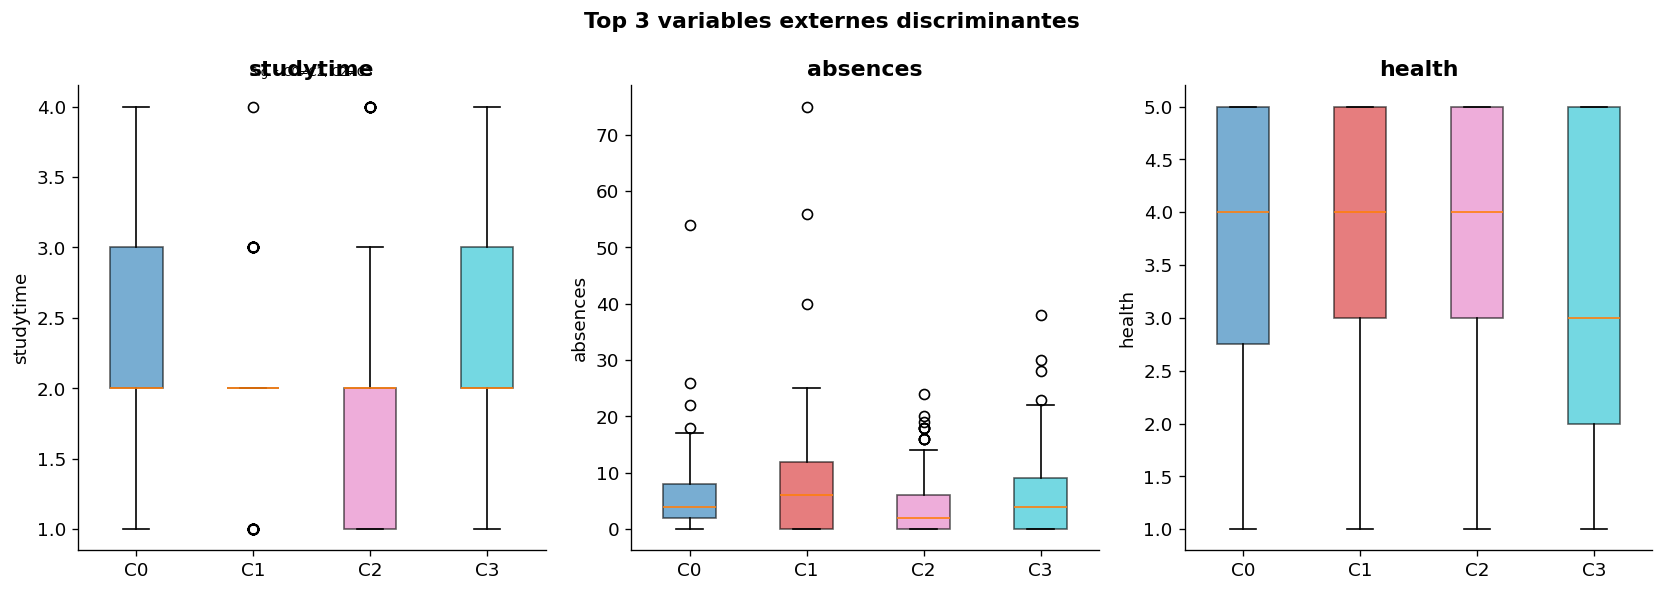

In [20]:
# ── Boxplots des 3 variables les plus discriminantes ──
top3 = tab_ext.head(3)['variable'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, var in zip(axes, top3):
    data = [mat_full.loc[labels_km == k, var].values for k in range(K)]
    bp = ax.boxplot(data, patch_artist=True, labels=[f'C{k}' for k in range(K)])
    for patch, k_idx in zip(bp['boxes'], range(K)):
        color = plt.cm.tab10(k_idx / max(K - 1, 1))
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(var, fontweight='bold')
    ax.set_ylabel(var)

    # Annotation paires significatives
    sig_pairs = []
    for c0, c1 in CLUSTER_PAIRS:
        _, p_pair = mannwhitneyu(data[c0], data[c1], alternative='two-sided')
        if p_pair < ALPHA_BONF:
            sig_pairs.append(f'C{c0}≠C{c1}')
    if sig_pairs:
        ax.text(0.5, 1.02, 'Sig. : ' + ', '.join(sig_pairs[:3]),
                transform=ax.transAxes, ha='center', fontsize=7)

plt.suptitle('Top 3 variables externes discriminantes', fontweight='bold')
plt.tight_layout()
plt.show()


**Conclusion — cohérence élargie**

Parmi les variables non utilisées dans le clustering (`VARS_EXT`), seules celles avec
p < 0,05 au test de Kruskal-Wallis discriminent significativement les K profils.
Les boxplots des variables les plus discriminantes complètent cette lecture.


## 13. Synthèse de la validation des profils

Run courant : **VARIANCE_THRESHOLD = 58 %** → **3 axes AFTD** ; silhouette → **K = 4 clusters**.

**Existence et significativité (§10).** Les tests globaux (Kruskal-Wallis / χ²) et post-hoc avec correction de Bonferroni sur 6 paires (α/6 = 0,0083) identifient quelles variables de construction séparent réellement les 4 profils. La séparation est réelle mais inégalement répartie : `paid`, `higher` et `failures` sont les variables les plus discriminantes.

**Stabilité et robustesse (§11).** Le bootstrap recalcule l'AFTD avec le seuil de 58 % et K-means avec K = 4 à chaque itération. La médiane ARI = **1,000** (P5 = P95 = 1,000) : la partition est parfaitement stable sur des sous-échantillons de 80 %.

**Limites et articulation avec le notebook 02.** (1) Effectif modeste (395 élèves, 38 décrocheurs, 4 clusters). (2) Centroïdes spécifiques à cette cohorte — la généralisation à d'autres lycées est à tester. (3) **Profil identifié ≠ décrochage prédit** : appartenir au cluster C1 (21,1 % de décrochage) caractérise un profil de vulnérabilité, mais ne constitue pas une prédiction individuelle. La prédiction supervisée à partir de G1, G2, G3 est traitée dans le notebook 02.